In [15]:
!pip install pandas_datareader yfinance scikit-learn matplotlib numpy

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf

In [19]:
company = 'AAPL'
df = yf.download(company, start='2015-01-01', end='2024-01-01')

# Fix multi-level columns
df.columns = df.columns.get_level_values(0).str.lower()
print(df.columns.tolist())  # should show ['close', 'high', 'low', 'open', 'volume']
print(df.head())

/tmp/ipykernel_2095/1006605074.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start='2015-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

['close', 'high', 'low', 'open', 'volume']
Price           close       high        low       open     volume
Date                                                             
2015-01-02  24.192606  24.659508  23.754470  24.648443  212818400
2015-01-05  23.511057  24.042131  23.325182  23.962469  257142000
2015-01-06  23.513277  23.772175  23.152589  23.575235  263188400
2015-01-07  23.842981  23.942557  23.610636  23.721276  160423600
2015-01-08  24.759087  24.816620  24.053201  24.170481  237458000


In [20]:
df.columns = df.columns.get_level_values(0).str.lower()

In [21]:
from google.colab import drive
drive.mount('/content/drive')
df.to_csv(f'/content/drive/MyDrive/{company}.csv')
print("Saved to Drive!")

Mounted at /content/drive
Saved to Drive!


In [22]:
df1 = df['close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
df1 = scaler.fit_transform(df1)

print("Scaled data shape:", df1.shape)
print("Sample values:", df1[:5])

Scaled data shape: (2264, 1)
Sample values: [[0.0206856 ]
 [0.01679829]
 [0.01681096]
 [0.01869147]
 [0.0239166 ]]


In [23]:
training_size = int(len(df1) * 0.70)
test_size = len(df1) - training_size

train_data = df1[0:training_size]
test_data = df1[training_size:]

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 1584
Test size: 680


In [24]:
timespan = int(input('Enter time span in days (e.g. 5, 10, 30): '))
print(f"Using timespan: {timespan} days")

Enter time span in days (e.g. 5, 10, 30): 10
Using timespan: 10 days


In [26]:
df1

array([[0.0206856 ],
       [0.01679829],
       [0.01681096],
       ...,
       [0.97202654],
       [0.97445174],
       [0.96852983]])

In [27]:
def create_dataset(dataset, span=1):
    x, y = [], []
    for i in range(len(dataset) - span):
        a = dataset[i:(i + span), 0]
        x.append(a)
        y.append(dataset[i + span, 0])
    return np.array(x), np.array(y)

In [28]:
x_train, y_train = create_dataset(train_data, timespan)
x_test, y_test = create_dataset(test_data, timespan)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1574, 10)
y_train shape: (1574,)
x_test shape: (670, 10)
y_test shape: (670,)


In [29]:
model = LinearRegression()
model.fit(x_train, y_train)
print("Model trained successfully!")
print(f"Model coefficient (first): {model.coef_[0]:.4f}")
print(f"Model intercept: {model.intercept_:.4f}")

Model trained successfully!
Model coefficient (first): -0.0767
Model intercept: 0.0002


In [30]:
train_predict = model.predict(x_train).reshape(-1, 1)
test_predict = model.predict(x_test).reshape(-1, 1)

# Inverse transform back to real prices
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")

Train RMSE: 1.2355
Test RMSE:  2.6692


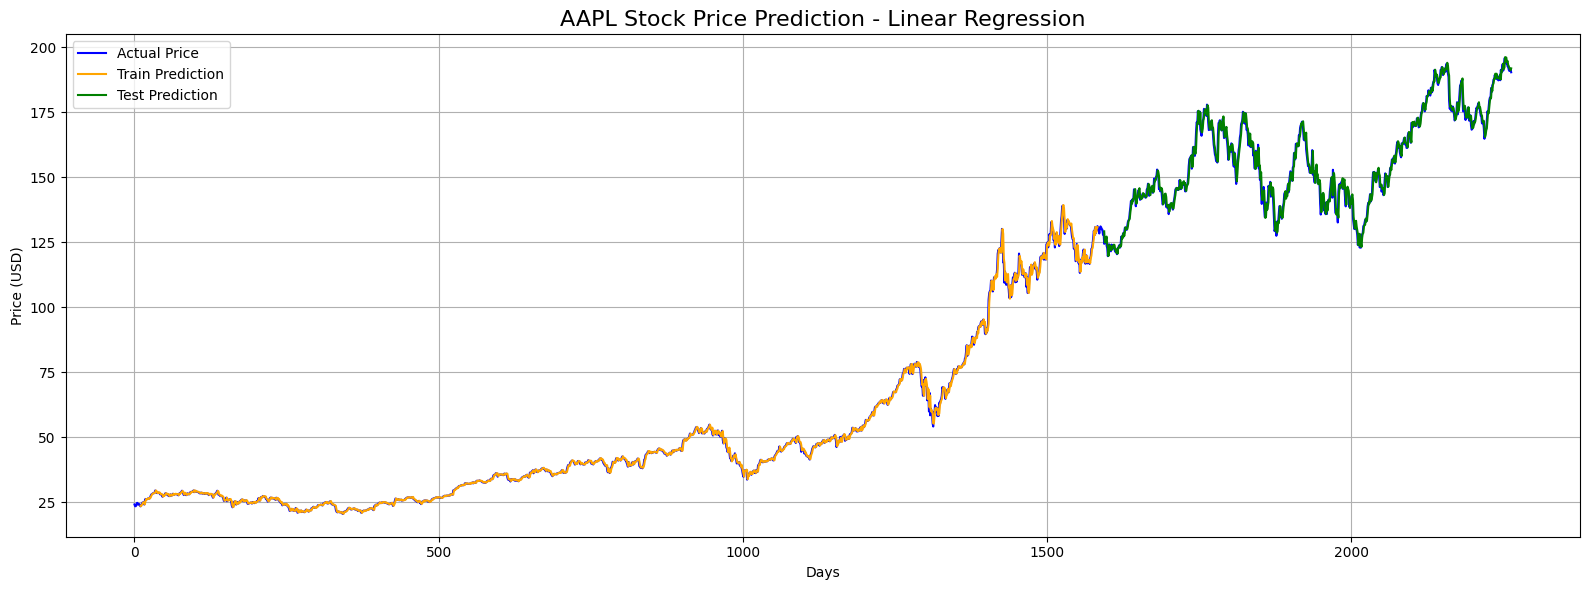

In [32]:
actual_prices = scaler.inverse_transform(df1)

train_plot = np.empty_like(actual_prices)
train_plot[:] = np.nan
train_plot[timespan:len(train_predict) + timespan] = train_predict

test_plot = np.empty_like(actual_prices)
test_plot[:] = np.nan

# Fix: calculate exact start index and clip to fit
test_start = len(train_predict) + (timespan * 2)
test_end = test_start + len(test_predict)
test_end = min(test_end, len(actual_prices))  # prevent overflow
test_predict_trimmed = test_predict[:test_end - test_start]

test_plot[test_start:test_end] = test_predict_trimmed

plt.figure(figsize=(16, 6))
plt.plot(actual_prices, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(train_plot, label='Train Prediction', color='orange', linewidth=1.5)
plt.plot(test_plot, label='Test Prediction', color='green', linewidth=1.5)
plt.title(f'{company} Stock Price Prediction - Linear Regression', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
l = len(test_data)
x_input = test_data[l - timespan:].reshape(1, -1)
temp_input = list(x_input[0])

print(f"Last {timespan} scaled values used as input:")
print(temp_input)

Last 10 scaled values used as input:
[np.float64(0.9969545389791739), np.float64(0.9874796069677334), np.float64(0.9934015156266396), np.float64(0.9815015635859274), np.float64(0.9806552782441016), np.float64(0.9745645302636055), np.float64(0.9714626734281449), np.float64(0.9720265445439089), np.float64(0.974451738634337), np.float64(0.9685298299754308)]


In [34]:
lst_output = []
n_steps = timespan
i = 1

while i <= 30:
    x_input = np.array(temp_input[-timespan:]).reshape(1, n_steps)
    yhat = model.predict(x_input)
    temp_input.append(yhat[0])
    lst_output.append(yhat[0])
    i += 1

print("30 days of scaled predictions done!")

30 days of scaled predictions done!


In [35]:
lst_output_arr = np.array(lst_output).reshape(-1, 1)
forecast = scaler.inverse_transform(lst_output_arr)

print(f"\n{company} Predicted Prices for Next 30 Days:\n")
for day, price in enumerate(forecast, 1):
    print(f"Day {day:2d}: ${price[0]:.2f}")


AAPL Predicted Prices for Next 30 Days:

Day  1: $190.53
Day  2: $190.97
Day  3: $191.04
Day  4: $191.30
Day  5: $191.47
Day  6: $191.80
Day  7: $191.98
Day  8: $192.29
Day  9: $192.49
Day 10: $192.75
Day 11: $193.05
Day 12: $193.31
Day 13: $193.60
Day 14: $193.86
Day 15: $194.15
Day 16: $194.42
Day 17: $194.70
Day 18: $194.98
Day 19: $195.26
Day 20: $195.55
Day 21: $195.82
Day 22: $196.11
Day 23: $196.39
Day 24: $196.67
Day 25: $196.96
Day 26: $197.24
Day 27: $197.52
Day 28: $197.81
Day 29: $198.09
Day 30: $198.38


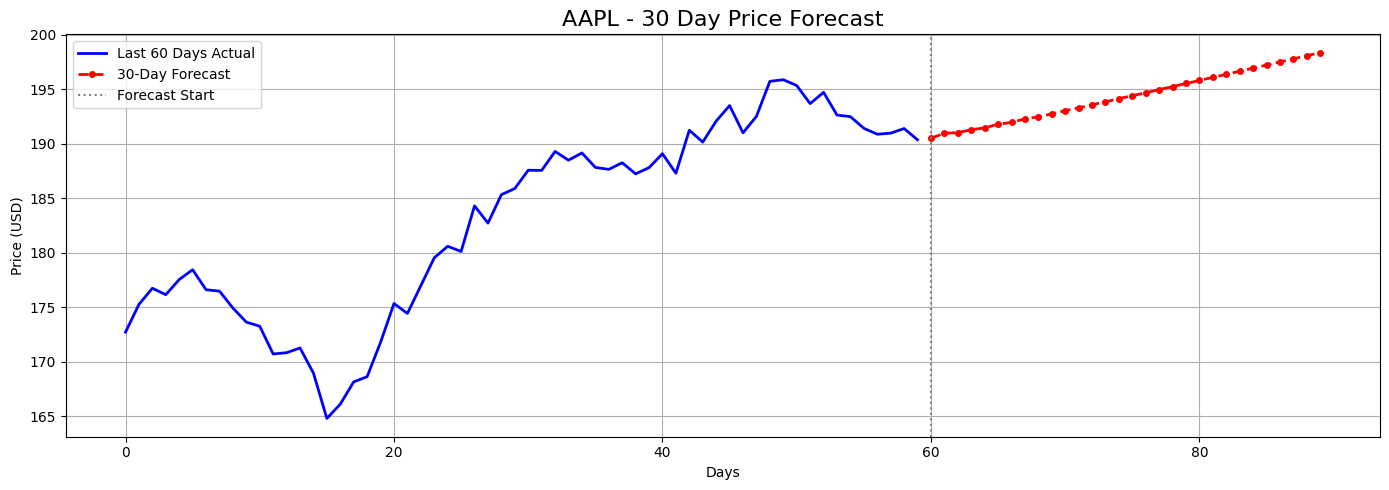

In [36]:
plt.figure(figsize=(14, 5))

# Show last 60 days of actual + 30 day forecast
last_60 = scaler.inverse_transform(df1[-60:])

plt.plot(range(60), last_60, label='Last 60 Days Actual', color='blue', linewidth=2)
plt.plot(range(60, 90), forecast, label='30-Day Forecast', color='red',
         linewidth=2, linestyle='--', marker='o', markersize=4)

plt.axvline(x=60, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title(f'{company} - 30 Day Price Forecast', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
print("=" * 40)
print(f"   STOCK PREDICTION SUMMARY: {company}")
print("=" * 40)
print(f"Total data points     : {len(df)}")
print(f"Training size         : {training_size}")
print(f"Test size             : {test_size}")
print(f"Timespan used         : {timespan} days")
print(f"Train RMSE            : ${train_rmse:.2f}")
print(f"Test RMSE             : ${test_rmse:.2f}")
print(f"Last actual price     : ${actual_prices[-1][0]:.2f}")
print(f"Day 1 forecast        : ${forecast[0][0]:.2f}")
print(f"Day 30 forecast       : ${forecast[29][0]:.2f}")
print("=" * 40)

   STOCK PREDICTION SUMMARY: AAPL
Total data points     : 2264
Training size         : 1584
Test size             : 680
Timespan used         : 10 days
Train RMSE            : $1.24
Test RMSE             : $2.67
Last actual price     : $190.38
Day 1 forecast        : $190.53
Day 30 forecast       : $198.38
